# 04 - Model Explainability

## Reliable Machine-Failure Prediction Under Imbalanced and Corrupted Sensor Data

The previous notebooks established the selected Random Forest model and
evaluated its robustness under sensor noise, missing sensor measurements,
and limited training data.

This notebook investigates how the selected model makes its predictions.

Two explainability methods are used:

1. Random Forest feature importance
2. SHAP analysis

Feature importance is used to identify which input variables have the
greatest overall influence on the Random Forest.

SHAP is then used to explain how individual feature values contribute to
specific machine-failure predictions.

The objective is to make the prediction system more interpretable and useful
for engineering decision-making.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

project_root = Path.cwd().parent

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Project root:", project_root)
print("Source path:", src_path)

Project root: c:\Users\aacaa\Documents\reliable-machine-failure-prediction
Source path: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\src


In [2]:
from data_loader import (
    load_ai4i_data,
    create_model_data
)

from preprocessing import create_preprocessor

print("Project functions imported successfully.")

Project functions imported successfully.


In [3]:
data = load_ai4i_data()

X, y = create_model_data(data)

print("Dataset shape:", data.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(list(X.columns))

print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (10000, 12)
Feature matrix shape: (10000, 6)
Target shape: (10000,)

Features:
['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temporary, y_train, y_temporary = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary data equally
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temporary,
    y_temporary,
    test_size=0.50,
    random_state=42,
    stratify=y_temporary
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("\nFailure counts:")
print("Training:", y_train.sum())
print("Validation:", y_validation.sum())
print("Test:", y_test.sum())

Training shape: (7000, 6)
Validation shape: (1500, 6)
Test shape: (1500, 6)

Failure counts:
Training: 237
Validation: 51
Test: 51


In [5]:
tree_preprocessor = create_preprocessor(
    scale_numeric=False
)

X_train_tree = tree_preprocessor.fit_transform(
    X_train
)

X_validation_tree = tree_preprocessor.transform(
    X_validation
)

X_test_tree = tree_preprocessor.transform(
    X_test
)

print("Training transformed shape:", X_train_tree.shape)
print("Validation transformed shape:", X_validation_tree.shape)
print("Test transformed shape:", X_test_tree.shape)

Training transformed shape: (7000, 8)
Validation transformed shape: (1500, 8)
Test transformed shape: (1500, 8)


In [6]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_tree,
    y_train
)

print("Selected Random Forest trained successfully.")

Selected Random Forest trained successfully.


In [7]:
feature_names = tree_preprocessor.get_feature_names_out()

print("Features used by the Random Forest:")

for name in feature_names:
    print(name)

Features used by the Random Forest:
numeric__Air temperature
numeric__Process temperature
numeric__Rotational speed
numeric__Torque
numeric__Tool wear
categorical__Type_H
categorical__Type_L
categorical__Type_M


In [8]:
feature_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": random_forest_model.feature_importances_
    }
)

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_df.round(4)
)

,Feature,Importance
0,numeric__Torque,0.3245
1,numeric__Rotational speed,0.2372
2,numeric__Tool wear,0.1671
3,numeric__Air temperature,0.1227
4,numeric__Process temperature,0.1221
5,categorical__Type_L,0.0123
6,categorical__Type_M,0.0083
7,categorical__Type_H,0.0058


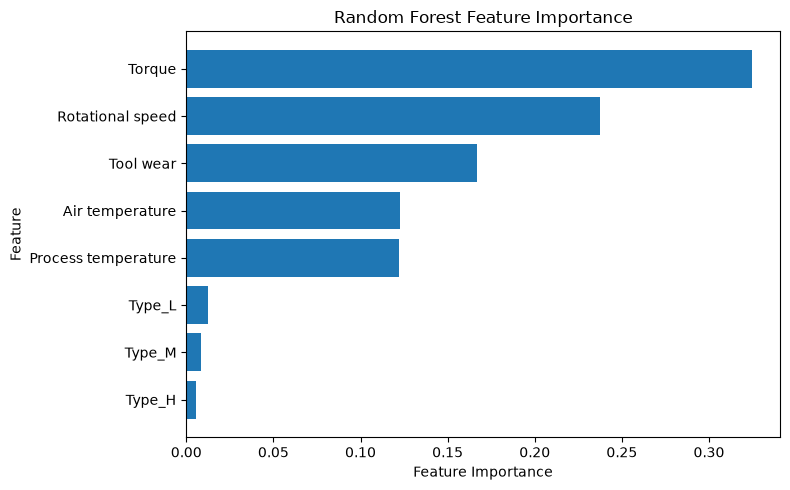

In [9]:
feature_importance_plot = feature_importance_df.copy()

feature_importance_plot["Feature"] = (
    feature_importance_plot["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance_plot = (
    feature_importance_plot
    .sort_values("Importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.set_title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Feature-Importance Findings

The Random Forest feature-importance analysis shows that torque is the most
influential input feature, with an importance score of approximately 32.45%.

Rotational speed is the second most important feature at approximately
23.72%, followed by tool wear at approximately 16.71%.

Air temperature and process temperature also contribute to the model, with
importance values of approximately 12.27% and 12.21%, respectively.

The encoded machine-type variables have much smaller importance scores than
the numerical operating measurements.

These results indicate that the Random Forest relies mainly on machine
operating conditions such as torque, rotational speed, and tool wear when
separating failure and non-failure cases.

Feature importance describes how useful each variable was for the Random
Forest's decision splits. It should not be interpreted as a direct causal
relationship with machine failure.

## 5. SHAP Analysis

Random Forest feature importance provides a global view of which variables
are important to the model overall.

However, it does not explain how a particular feature value influences an
individual prediction.

SHAP analysis is used to provide both global and local explanations.

SHAP values indicate how each feature pushes a prediction toward either
machine failure or no failure.

This allows the model's decisions to be interpreted in more detail.

In [11]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [12]:
explainer = shap.TreeExplainer(
    random_forest_model
)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [13]:
shap_values = explainer.shap_values(
    X_test_tree
)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


In [14]:
print("Type of SHAP output:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))

    for i, values in enumerate(shap_values):
        print(
            f"SHAP array {i} shape:",
            values.shape
        )
else:
    print(
        "SHAP values shape:",
        np.array(shap_values).shape
    )

Type of SHAP output: <class 'numpy.ndarray'>
SHAP values shape: (1500, 8, 2)


In [15]:
failure_shap_values = shap_values[:, :, 1]

print(
    "Failure-class SHAP values shape:",
    failure_shap_values.shape
)

Failure-class SHAP values shape: (1500, 8)


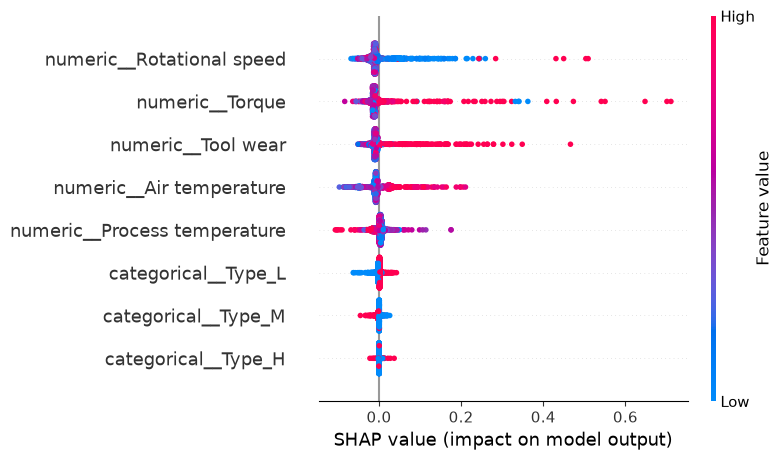

In [16]:
shap.summary_plot(
    failure_shap_values,
    X_test_tree,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Global SHAP Findings

The SHAP summary plot provides additional information about both the
importance and direction of individual feature effects on the Random Forest
failure predictions.

Torque shows a strong positive contribution for many high-value observations.
This indicates that higher torque values generally push the model toward
predicting machine failure.

Rotational speed also has a strong influence. Lower rotational-speed values
frequently produce positive SHAP values, indicating that certain low-speed
operating conditions increase the model's predicted failure risk.

Higher tool-wear values generally push predictions toward failure, while
higher air-temperature values also tend to increase predicted failure risk.

Process temperature shows a weaker and more mixed relationship with the
model output.

The encoded machine-type variables have SHAP values concentrated close to
zero, indicating that machine type contributes relatively little compared
with the numerical operating measurements.

Overall, the SHAP analysis supports the earlier feature-importance results
while also showing the direction in which individual feature values
influence failure predictions.

These relationships describe the behaviour learned by the Random Forest and
should not be interpreted as direct causal relationships with machine failure.

In [17]:
# Find the first actual failure case in the test set
failure_indices = np.where(y_test.to_numpy() == 1)[0]

selected_failure_index = failure_indices[0]

print(
    "Selected failure-case index:",
    selected_failure_index
)

print(
    "Actual class:",
    y_test.iloc[selected_failure_index]
)

Selected failure-case index: 35
Actual class: 1


In [21]:
selected_threshold = 0.20

print("Selected decision threshold:", selected_threshold)

Selected decision threshold: 0.2


In [22]:
selected_failure_probability = random_forest_model.predict_proba(
    X_test_tree[selected_failure_index].reshape(1, -1)
)[0, 1]

selected_failure_prediction = int(
    selected_failure_probability >= selected_threshold
)

print("Actual class:", y_test.iloc[selected_failure_index])
print("Predicted failure probability:", round(selected_failure_probability, 4))
print("Predicted class:", selected_failure_prediction)

Actual class: 1
Predicted failure probability: 0.94
Predicted class: 1


In [23]:
selected_machine_shap = failure_shap_values[
    selected_failure_index
]

selected_machine_features = X_test_tree[
    selected_failure_index
]

print(
    "Number of SHAP values:",
    len(selected_machine_shap)
)

print(
    "Number of transformed features:",
    len(selected_machine_features)
)

Number of SHAP values: 8
Number of transformed features: 8


In [27]:
selected_machine_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Feature Value": selected_machine_features,
    "SHAP Value": selected_machine_shap
})

selected_machine_explanation["Absolute SHAP"] = (
    selected_machine_explanation["SHAP Value"].abs()
)

selected_machine_explanation = (
    selected_machine_explanation
    .sort_values("Absolute SHAP", ascending=False)
    .reset_index(drop=True)
)

selected_machine_explanation

,Feature,Feature Value,SHAP Value,Absolute SHAP
0,numeric__Rotational speed,2737.0,0.503585,0.503585
1,numeric__Torque,8.8,0.362470,0.362470
2,categorical__Type_L,1.0,0.009614,0.009614
3,categorical__Type_H,0.0,0.009148,0.009148
4,numeric__Tool wear,142.0,0.008680,0.008680
5,numeric__Process temperature,310.2,0.007500,0.007500
6,categorical__Type_M,0.0,0.003062,0.003062
7,numeric__Air temperature,298.9,0.002072,0.002072


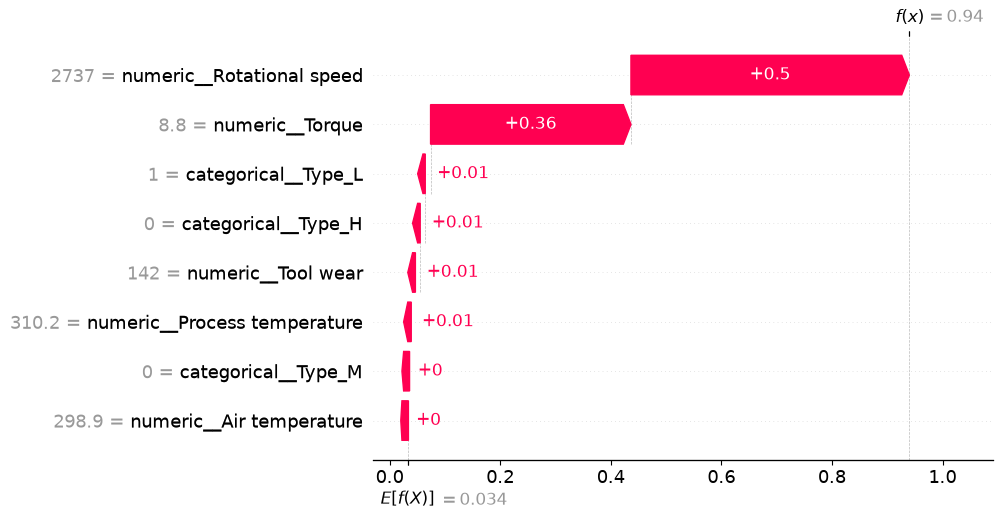

In [28]:
shap.plots.waterfall(
    shap.Explanation(
        values=selected_machine_shap,
        base_values=explainer.expected_value[1],
        data=selected_machine_features,
        feature_names=feature_names
    ),
    max_display=8
)

In [29]:
test_probabilities = random_forest_model.predict_proba(X_test_tree)[:, 1]

test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

false_negative_indices = np.where(
    (y_test.to_numpy() == 1) &
    (test_predictions == 0)
)[0]

print("Number of false negatives:", len(false_negative_indices))
print("First false-negative indices:", false_negative_indices[:10])

Number of false negatives: 9
First false-negative indices: [ 170  361  416  769  900 1122 1168 1204 1423]


In [30]:
selected_fn_index = false_negative_indices[0]

selected_fn_probability = test_probabilities[selected_fn_index]
selected_fn_prediction = test_predictions[selected_fn_index]

print("Selected false-negative index:", selected_fn_index)
print("Actual class:", y_test.iloc[selected_fn_index])
print("Predicted failure probability:", round(selected_fn_probability, 4))
print("Predicted class:", selected_fn_prediction)

Selected false-negative index: 170
Actual class: 1
Predicted failure probability: 0.1367
Predicted class: 0


In [31]:
selected_fn_shap = failure_shap_values[selected_fn_index]
selected_fn_features = X_test_tree[selected_fn_index]

selected_fn_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Feature Value": selected_fn_features,
    "SHAP Value": selected_fn_shap
})

selected_fn_explanation["Absolute SHAP"] = (
    selected_fn_explanation["SHAP Value"].abs()
)

selected_fn_explanation = (
    selected_fn_explanation
    .sort_values("Absolute SHAP", ascending=False)
    .reset_index(drop=True)
)

selected_fn_explanation

,Feature,Feature Value,SHAP Value,Absolute SHAP
0,numeric__Rotational speed,1371.0,0.091049,0.091049
1,numeric__Air temperature,303.6,0.090578,0.090578
2,numeric__Process temperature,312.2,-0.068368,0.068368
3,numeric__Tool wear,112.0,-0.020574,0.020574
4,numeric__Torque,54.6,0.014263,0.014263
5,categorical__Type_L,0.0,-0.004672,0.004672
6,categorical__Type_H,1.0,0.001033,0.001033
7,categorical__Type_M,0.0,-0.000511,0.000511


For the selected false-negative case, the model received conflicting evidence from the input features. Rotational speed and air temperature pushed the prediction toward failure, while process temperature and tool wear pushed it away from the failure class. Torque contributed only weakly compared with the earlier correctly detected failure. As a result, the combined evidence was insufficient to raise the predicted failure probability above the fixed 0.20 threshold, leading to a missed failure.

In [32]:
comparison_df = pd.DataFrame({
    "Feature": feature_names,
    "True Positive SHAP": selected_machine_shap,
    "False Negative SHAP": selected_fn_shap
})

comparison_df["Difference"] = (
    comparison_df["True Positive SHAP"]
    - comparison_df["False Negative SHAP"]
)

comparison_df = (
    comparison_df
    .sort_values(
        "Difference",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_df

,Feature,True Positive SHAP,False Negative SHAP,Difference
0,numeric__Rotational speed,0.503585,0.091049,0.412536
1,numeric__Torque,0.362470,0.014263,0.348206
2,numeric__Air temperature,0.002072,0.090578,-0.088506
3,numeric__Process temperature,0.007500,-0.068368,0.075867
4,numeric__Tool wear,0.008680,-0.020574,0.029255
5,categorical__Type_L,0.009614,-0.004672,0.014287
6,categorical__Type_H,0.009148,0.001033,0.008115
7,categorical__Type_M,0.003062,-0.000511,0.003574


Comparing the correctly detected failure with the false-negative case shows that rotational speed and torque were the main factors separating the two predictions. The true-positive machine received substantially larger positive SHAP contributions from both features, whereas the missed failure showed only weak positive contributions from these variables. In addition, process temperature and tool wear contributed negatively in the false-negative case. This suggests that the missed failure did not exhibit the same strong feature pattern that the Random Forest had learned to associate with machine failure.

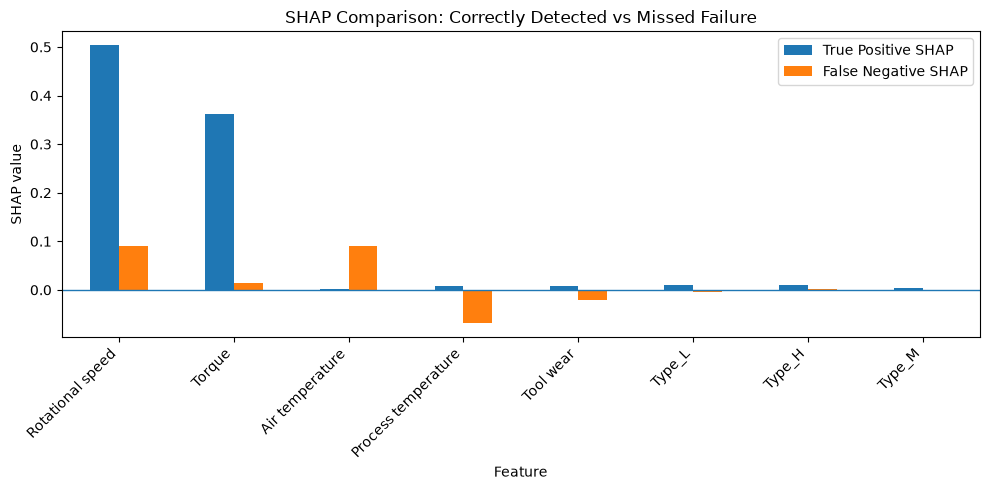

In [33]:
comparison_plot_df = comparison_df.copy()

comparison_plot_df["Feature"] = (
    comparison_plot_df["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

comparison_plot_df.plot(
    x="Feature",
    y=["True Positive SHAP", "False Negative SHAP"],
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0, linewidth=1)
plt.ylabel("SHAP value")
plt.title("SHAP Comparison: Correctly Detected vs Missed Failure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### SHAP Analysis Summary

The SHAP analysis provides both global and individual explanations for the Random Forest machine-failure predictions.

At the global level, rotational speed and torque were among the most influential variables affecting failure predictions. Tool wear and temperature measurements also contributed to the model output, while the encoded machine-type variables generally had smaller effects.

The individual true-positive example demonstrated that a machine with a predicted failure probability of 0.94 was strongly influenced by rotational speed and torque. These two features produced substantially larger positive SHAP values than the remaining variables, explaining why the model confidently classified the machine as a failure.

In contrast, the selected false-negative machine received a predicted failure probability of only 0.1367, which remained below the fixed decision threshold of 0.20. Although rotational speed and air temperature pushed the prediction toward failure, process temperature and tool wear contributed negatively, while torque produced only a weak positive contribution.

The comparison between the correctly detected and missed failure therefore shows that the model is more confident when a machine exhibits feature combinations that strongly resemble the failure patterns learned during training. Actual failures that do not exhibit these strong learned patterns may remain below the classification threshold and consequently be missed.

These findings help explain why the selected Random Forest achieved high failure recall but did not detect every real failure. Explainability therefore provides additional insight beyond performance metrics by identifying the feature patterns associated with both successful and unsuccessful failure detection.

The SHAP results describe associations learned by the Random Forest and should not be interpreted as evidence of direct physical causation.

## 6. Explainability Conclusion

The explainability analysis provides complementary global and local insights into the behaviour of the selected Random Forest machine-failure prediction system.

The impurity-based feature-importance analysis identified torque as the most influential feature overall, accounting for approximately 32.45% of the model's total feature importance. Rotational speed and tool wear also contributed substantially, while temperature measurements had more moderate importance and the encoded machine-type variables contributed relatively little.

SHAP analysis extended these findings by showing not only which features were influential but also how individual feature values affected predictions. At the global level, rotational speed, torque, tool wear, and temperature measurements produced the strongest effects on predicted failure risk.

The individual case analysis demonstrated that the model can make highly confident failure predictions when a machine exhibits a strong combination of learned failure-associated feature patterns. The selected correctly detected failure received a predicted failure probability of 0.94 and was driven primarily by large positive SHAP contributions from rotational speed and torque.

However, analysis of a false-negative case showed that actual failures may also exhibit more ambiguous feature combinations. The selected missed failure received a probability of only 0.1367, below the fixed decision threshold of 0.20. Although some features pushed the prediction toward failure, these effects were weaker and were partly offset by features pushing the prediction away from failure.

Together, these findings demonstrate that explainability can reveal why the same model succeeds confidently for some failure cases while missing others. This is particularly important for predictive-maintenance applications, where understanding missed failures is necessary when evaluating model reliability.

The explainability results should be interpreted as descriptions of patterns learned by the Random Forest rather than evidence of direct physical causation between individual sensor measurements and machine failure.

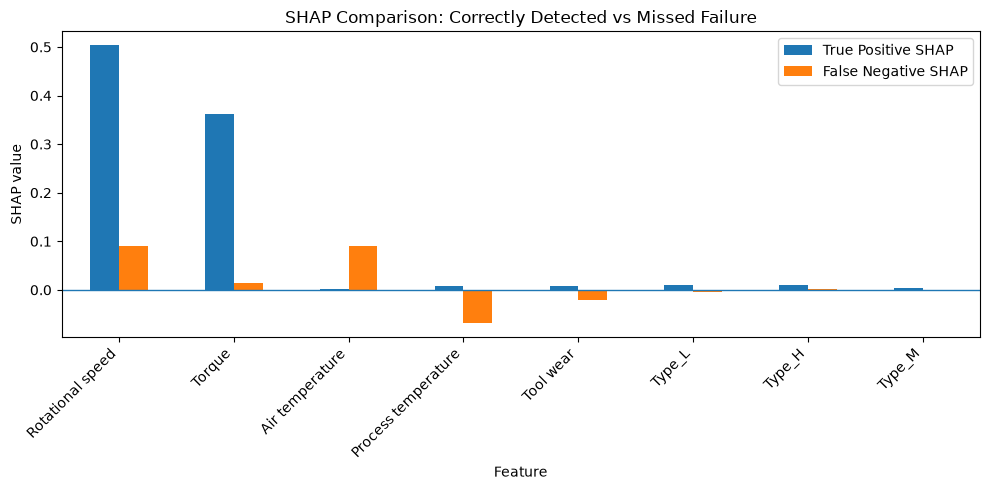

In [34]:
comparison_plot_df = comparison_df.copy()

comparison_plot_df["Feature"] = (
    comparison_plot_df["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

ax = comparison_plot_df.plot(
    x="Feature",
    y=["True Positive SHAP", "False Negative SHAP"],
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0, linewidth=1)
plt.ylabel("SHAP value")
plt.title("SHAP Comparison: Correctly Detected vs Missed Failure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "../results/shap_true_positive_vs_false_negative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
selected_machine_explanation.to_csv(
    "../results/shap_true_positive_explanation.csv",
    index=False
)

selected_fn_explanation.to_csv(
    "../results/shap_false_negative_explanation.csv",
    index=False
)

comparison_df.to_csv(
    "../results/shap_true_positive_vs_false_negative.csv",
    index=False
)

print("SHAP explanation tables saved successfully.")

SHAP explanation tables saved successfully.


## 7. Notebook Summary

This notebook investigated how the selected Random Forest machine-failure prediction system makes its decisions.

Impurity-based feature importance showed that torque was the most influential feature overall, accounting for approximately 32.45% of the model's total feature importance. Rotational speed and tool wear also played substantial roles, while temperature measurements had more moderate importance and machine type contributed relatively little.

SHAP analysis provided additional insight by showing both the magnitude and direction of individual feature effects. The global SHAP results demonstrated that operating measurements such as rotational speed, torque, tool wear, and temperature strongly influence the model's predicted failure risk.

Individual case analysis showed that the correctly detected failure received a high failure probability of 0.94, driven primarily by strong positive SHAP contributions from rotational speed and torque.

In contrast, the selected false-negative case received a probability of only 0.1367. Although rotational speed and air temperature provided some evidence toward failure, process temperature and tool wear pushed the prediction in the opposite direction, while torque contributed only weakly.

These findings demonstrate that model explainability can help identify why certain failures are detected confidently while other genuine failures are missed.

Together with the previous robustness experiments, this analysis shows that evaluating a predictive-maintenance system requires more than clean-data accuracy. Reliable failure prediction also depends on robustness to imperfect data and an understanding of the feature patterns that drive individual predictions.